# 4. Is it grazing?

Notebooks 2 and 3 found that clipped biomass, relative to rain and summer temperature, fell over 2011–2020 across many sites, and that the decline rests on both ends of the decade. Over the same years the national herd doubled. This notebook asks whether grazing explains the decline, in three parts:

- **Greenness.** Does satellite greenness at the same sites fall too, and could it have shown a decline of this size?
- **Herds.** Did soums whose herds grew most lose the most biomass? Did the 2009–2010 dzud leave a mark?
- **Seasonal pastures.** Is the decline stronger on summer pastures, which are grazed before the August clipping?

The tests of the herd and pasture sections were set before they were run. Every model uses the rain and temperature remainders.

- **Reads** `sites.csv`, `site_year.csv` and `flags.csv` from `data/processed/`, and the greenness, weather and herd tables of the release.
- **Writes** `soums.csv`, `herd_tests.csv` and `pasture_tests.csv` to `data/processed/`.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf

from mn_desertification import data, grazing, paths, quality, trends
from mn_desertification.rules import FLOOR, MAIN_YEARS, ZONES
from mn_desertification.weather import weather_remainders

weather = data.read_soum_weather()
site_info = pd.read_csv(paths.PROCESSED_DIR / "sites.csv")
flags = pd.read_csv(paths.PROCESSED_DIR / "flags.csv")
site_year = pd.read_csv(paths.PROCESSED_DIR / "site_year.csv")
site_year = site_year.merge(weather[["asid", "year", "temp_summer"]], on=["asid", "year"], how="left")

# Biomass in the main period, as in notebook 2: floor, flags out, rain and temperature removed
biomass = quality.drop_flagged(site_year[site_year["year"].between(*MAIN_YEARS)], flags).copy()
biomass["bms_floored"] = biomass["bms"].clip(lower=FLOOR)
bio_rem = weather_remainders(biomass, "bms_floored")
print("Biomass site-years:", len(bio_rem), "| sites:", bio_rem["gid"].nunique())

Biomass site-years: 13367 | sites: 1485


## Satellite greenness at the same sites

The release holds MODIS vegetation indices for every site, 2000–2024. They come from MODIS reflectance at 500 m resolution, taken within 100 m of each plot (Purevjav et al. 2025, supplementary text pp. S2 and S4), so they describe the land around a plot rather than the plot itself. Greenness here is NDVI, analysed like biomass: in logs, each site against its own average, with rain and summer temperature removed zone by zone.

In [2]:
greenness = data.read_greenness(indices=("ndvi", "evi", "savi", "msavi", "nirv"))
greenness = greenness.merge(site_info[["gid", "asid"]], on="gid").merge(weather, on=["asid", "year"], how="left")
print("Site-years:", len(greenness), "| years:", greenness["year"].min(), "to", greenness["year"].max(),
      "| missing NDVI:", greenness["ndvi"].isna().sum())

green_main = weather_remainders(greenness[greenness["year"].between(*MAIN_YEARS)], "ndvi")
green_long = weather_remainders(greenness, "ndvi")   # 2000-2024, fitted on all 25 years

Site-years: 37200 | years: 2000 to 2024 | missing NDVI: 63


Correlation of the two yearly series: 0.53
Years with the same sign: 8 of 10
Standard deviation of the yearly means: {'biomass': 0.095, 'greenness': 0.019}


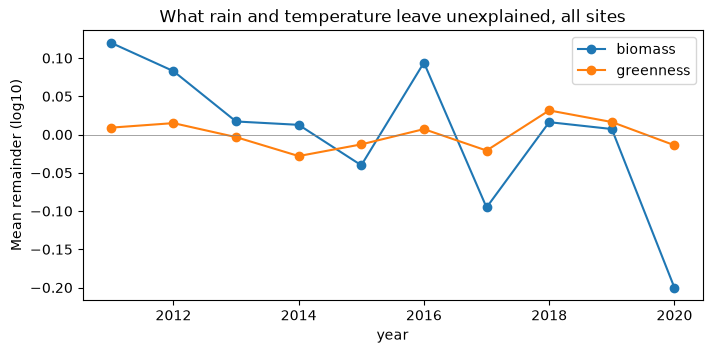

year,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020
biomass,0.120,0.083,0.017,0.013,-0.040,0.094,-0.095,0.016,0.007,-0.200
greenness,0.009,0.015,-0.003,-0.028,-0.013,0.007,-0.021,0.032,0.016,-0.014


In [3]:
yearly = pd.DataFrame({"biomass": trends.yearly_mean(bio_rem), "greenness": trends.yearly_mean(green_main)})
print("Correlation of the two yearly series:", round(yearly["biomass"].corr(yearly["greenness"]), 2))
print("Years with the same sign:", (np.sign(yearly["biomass"]) == np.sign(yearly["greenness"])).sum(), "of", len(yearly))
print("Standard deviation of the yearly means:", yearly.std().round(3).to_dict())

ax = yearly.plot(marker="o", figsize=(8, 3.5))
ax.axhline(0, color="grey", linewidth=0.5)
ax.set_ylabel("Mean remainder (log10)")
ax.set_title("What rain and temperature leave unexplained, all sites")
plt.show()
yearly.round(3).T

The two series agree on good and bad years. Their yearly means correlate at 0.53 and have the same sign in 8 of the 10 years. But greenness moves far less, about a fifth as much, and only biomass drifts down.

In [4]:
summary = []
for name, remainders, min_years in [("biomass 2011-2020", bio_rem, 8),
                                    ("greenness 2011-2020", green_main, 8),
                                    ("greenness 2000-2024", green_long, 20)]:
    trend, low, high = trends.mean_trend(remainders)
    sites_tested = trends.site_trends(remainders, min_years=min_years)
    summary.append({"series": name,
                    "trend per decade": round(trend, 3),
                    "95% range": f"{low:+.3f} to {high:+.3f}",
                    "% per decade": round(float(trends.percent_per_decade(trend)), 1),
                    "sites tested": len(sites_tested),
                    "sites declining": round((sites_tested["p_decline"] < 0.05).mean(), 3)})
pd.DataFrame(summary)

,series,trend per decade,95% range,% per decade,sites tested,sites declining
0,biomass 2011-2020,-0.219,-0.403 to -0.034,-39.5,1250,0.205
1,greenness 2011-2020,0.001,-0.050 to +0.052,0.3,1487,0.050
2,greenness 2000-2024,0.033,+0.021 to +0.044,7.9,1486,0.007


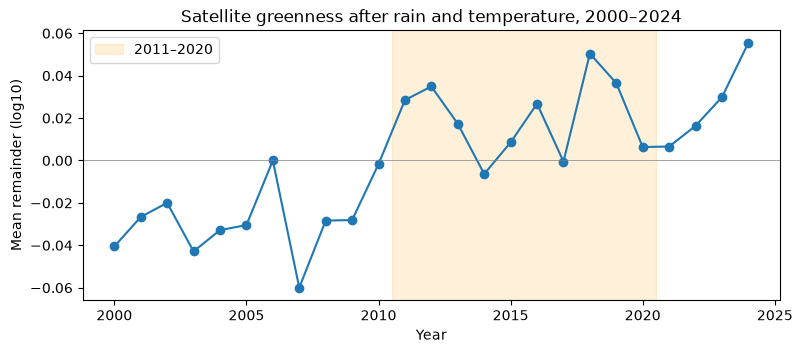

In [5]:
long_yearly = trends.yearly_mean(green_long)

fig, ax = plt.subplots(figsize=(9, 3.5))
ax.axvspan(2010.5, 2020.5, color="orange", alpha=0.15, label="2011–2020")
ax.plot(long_yearly.index, long_yearly.values, marker="o")
ax.axhline(0, color="grey", linewidth=0.5)
ax.set_xlabel("Year")
ax.set_ylabel("Mean remainder (log10)")
ax.set_title("Satellite greenness after rain and temperature, 2000–2024")
ax.legend()
plt.show()

Greenness did not decline over 2011–2020: its trend is +0.001 log10 per decade, and 5.0% of sites decline, as many as chance alone gives. Over 2000–2024 it rose, and 2011–2020 lies above the 2000s.

### Could greenness have shown a decline this large?

That depends on how closely greenness follows biomass, measured in two ways: from year to year, with the yearly means above, and between sites, with each site's 2011–2020 averages. "In step" multiplies that slope by the biomass trend, to give the greenness trend expected if greenness had followed biomass down.

year to year: slope 0.10; in step with biomass, greenness would change -0.023 per decade
between sites: slope 0.60; in step with biomass, greenness would change -0.131 per decade


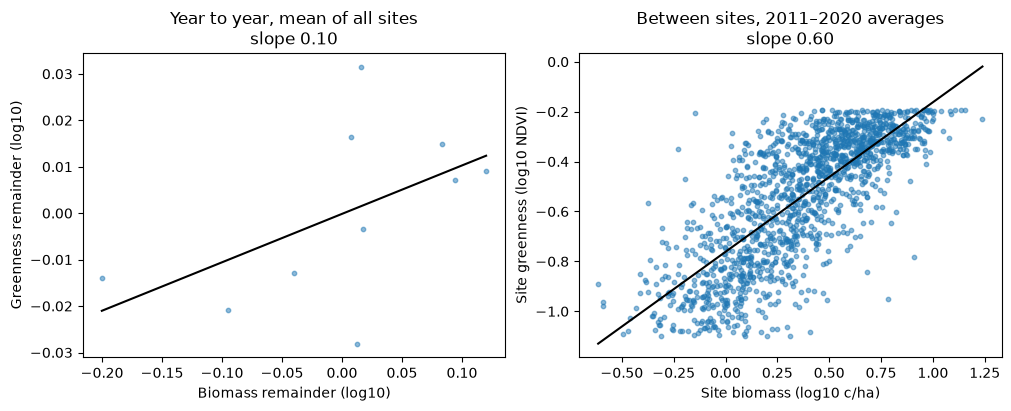

In [6]:
green_10 = greenness[greenness["year"].between(*MAIN_YEARS)]
site_means = pd.DataFrame({
    "biomass": np.log10(biomass["bms_floored"]).groupby(biomass["gid"]).mean(),
    "greenness": np.log10(green_10["ndvi"]).groupby(green_10["gid"]).mean(),
}).dropna()
site_means["zone"] = bio_rem.groupby("gid")["zone"].first()

fit_years = np.polyfit(yearly["biomass"], yearly["greenness"], 1)
fit_sites = np.polyfit(site_means["biomass"], site_means["greenness"], 1)
bio_trend = trends.mean_trend(bio_rem)[0]
for name, line in [("year to year", fit_years), ("between sites", fit_sites)]:
    print(f"{name}: slope {line[0]:.2f}; in step with biomass, greenness would change {line[0] * bio_trend:+.3f} per decade")

fig, axes = plt.subplots(1, 2, figsize=(10, 4), layout="constrained")
panels = [(axes[0], yearly, fit_years, "Year to year, mean of all sites", "Biomass remainder (log10)", "Greenness remainder (log10)"),
          (axes[1], site_means, fit_sites, "Between sites, 2011–2020 averages", "Site biomass (log10 c/ha)", "Site greenness (log10 NDVI)")]
for ax, table, line, title, xlabel, ylabel in panels:
    ax.scatter(table["biomass"], table["greenness"], s=10, alpha=0.5)
    ends = np.array([table["biomass"].min(), table["biomass"].max()])
    ax.plot(ends, np.polyval(line, ends), color="black")
    ax.set_title(f"{title}\nslope {line[0]:.2f}")
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
plt.show()

In [7]:
# The relation between sites is not a straight line: its slope within four bands of biomass
bands = pd.cut(10 ** site_means["biomass"], [0, 1, 2, 4, 100])
band_rows = []
for band, group in site_means.groupby(bands, observed=True):
    band_rows.append({"biomass (c/ha)": str(band), "sites": len(group),
                      "slope": round(np.polyfit(group["biomass"], group["greenness"], 1)[0], 2),
                      "typical NDVI": round(10 ** group["greenness"].mean(), 3)})
pd.DataFrame(band_rows)

,biomass (c/ha),sites,slope,typical NDVI
0,"(0, 1]",205,0.21,0.133
1,"(1, 2]",402,0.83,0.211
2,"(2, 4]",483,0.81,0.348
3,"(4, 100]",395,0.31,0.472


- **From year to year** greenness changes by only 0.10 log10 per log10 of biomass. At that rate the biomass decline would lower greenness by 0.023 per decade, inside greenness's 95% range (−0.050 to +0.052). Ten years of greenness could not have shown it.
- **Between sites** greenness changes by 0.60. If a lasting loss moved greenness as the differences between sites do, greenness would have fallen by 0.131 per decade, far outside the range.
- **The relation between sites is curved.** It is steep between 1 and 4 c/ha (slope 0.8). Below 1 c/ha it is flat (0.2), where desert sites are hardly greener than bare ground (NDVI about 0.13), and above 4 c/ha it flattens again (0.3), where greenness stops rising in denser grass.

### Where the decline is

In [8]:
zone_rows = []
for zone in ZONES:
    bio_zone = bio_rem[bio_rem["zone"] == zone]
    green_zone = green_main[green_main["zone"] == zone]
    means_zone = site_means[site_means["zone"] == zone]
    bio_trend_zone = trends.mean_trend(bio_zone)[0]
    green_trend_zone, low, high = trends.mean_trend(green_zone)
    slope_years = np.polyfit(trends.yearly_mean(bio_zone), trends.yearly_mean(green_zone), 1)[0]
    slope_sites = np.polyfit(means_zone["biomass"], means_zone["greenness"], 1)[0]
    zone_rows.append({"zone": zone, "sites": len(means_zone),
                      "biomass trend": round(bio_trend_zone, 3),
                      "greenness trend": round(green_trend_zone, 3),
                      "greenness 95% range": f"{low:+.3f} to {high:+.3f}",
                      "expected, year to year": round(slope_years * bio_trend_zone, 3),
                      "expected, between sites": round(slope_sites * bio_trend_zone, 3)})
pd.DataFrame(zone_rows)

,zone,sites,biomass trend,greenness trend,greenness 95% range,"expected, year to year","expected, between sites"
0,Desert zone,112,-0.412,-0.014,-0.056 to +0.029,-0.029,-0.011
1,Semi desert steppe zone,323,-0.434,-0.008,-0.052 to +0.036,-0.023,-0.165
2,Steppe zone,627,-0.233,-0.005,-0.068 to +0.057,-0.028,-0.094
3,Forest steppe zone,374,0.011,0.024,-0.040 to +0.088,0.002,0.002
4,Mountain taiga belt,49,-0.024,0.006,-0.020 to +0.032,-0.002,-0.002


- **The biomass decline is in the three dry zones.** The desert, semi-desert steppe and steppe decline, and the forest steppe and mountain taiga do not.
- **In the steppe and semi-desert steppe,** a decline at the between-site rate falls outside the greenness range, so it would have shown. One at the year-to-year rate would not.
- **In the desert,** greenness barely differs between sites with more or less biomass, so it cannot test the decline there.

### How much rests on 2020

The 2020 drought in the south-central Gobi (notebook 1) was the last year of the period, so it weighs heavily on any trend. Here the weather model is refitted without it.

In [9]:
print("Mean remainder in 2020 by zone:", bio_rem[bio_rem["year"] == 2020].groupby("zone")["remainder"].mean().reindex(ZONES).round(3).to_dict())

bio_2019 = weather_remainders(biomass[biomass["year"] <= 2019], "bms_floored")
rows = []
for zone in ["all zones"] + ZONES:
    with_2020 = bio_rem if zone == "all zones" else bio_rem[bio_rem["zone"] == zone]
    without = bio_2019 if zone == "all zones" else bio_2019[bio_2019["zone"] == zone]
    trend, low, high = trends.mean_trend(without)
    rows.append({"zone": zone, "with 2020": round(trends.mean_trend(with_2020)[0], 3),
                 "without 2020": round(trend, 3), "95% range without 2020": f"{low:+.3f} to {high:+.3f}"})
pd.DataFrame(rows)

Mean remainder in 2020 by zone: {'Desert zone': -0.36, 'Semi desert steppe zone': -0.348, 'Steppe zone': -0.196, 'Forest steppe zone': -0.057, 'Mountain taiga belt': -0.082}


,zone,with 2020,without 2020,95% range without 2020
0,all zones,-0.219,-0.093,-0.309 to +0.123
1,Desert zone,-0.412,-0.202,-0.555 to +0.150
2,Semi desert steppe zone,-0.434,-0.217,-0.464 to +0.031
3,Steppe zone,-0.233,-0.123,-0.333 to +0.088
4,Forest steppe zone,0.011,0.075,-0.312 to +0.462
5,Mountain taiga belt,-0.024,0.017,-0.087 to +0.120


In 2020 the dry zones fell 0.2–0.36 log10 below what the weather model predicts. The model saw the drought but under-predicted how hard it hit. Refitted without 2020, the national trend more than halves, from −0.219 to −0.093 per decade, and no zone's 95% range then excludes zero. Notebook 3 shows the same in its robustness check.

### Other indices

NDVI can respond poorly where soil shows between plants. SAVI and MSAVI correct for bare soil, EVI for dense cover and haze, and NIRv tracks photosynthesis more closely.

In [10]:
indices = greenness[greenness["year"].between(*MAIN_YEARS)]
for index in ["ndvi", "evi", "savi", "msavi", "nirv"]:
    trend, low, high = trends.mean_trend(weather_remainders(indices, index))
    print(f"{index}: {trend:+.3f} per decade, 95% range {low:+.3f} to {high:+.3f}")

ndvi: +0.001 per decade, 95% range -0.050 to +0.052
evi: +0.008 per decade, 95% range -0.046 to +0.062
savi: +0.007 per decade, 95% range -0.043 to +0.057
msavi: +0.009 per decade, 95% range -0.044 to +0.063
nirv: +0.014 per decade, 95% range -0.049 to +0.077


**In short.** Greenness around the plots shows no decline over 2011–2020, in any zone or with any of five indices. That rules out a large lasting loss of green cover in the steppe and semi-desert steppe. It does not rule out a smaller loss, a loss confined to the plots, or a shift towards unpalatable plants, which can lower biomass while keeping greenness up: on six fence-line pairs in the Mongolian steppe, grazed sides had less than half the biomass of fenced ones but higher greenness (Karnieli et al. 2013). In the desert greenness cannot test the decline at all.

## Herds

Herds come from the December livestock census in the release, in sheep units (horse 7, cattle 6, camel 5, sheep 1, goat 0.9, the National Statistics Office's weights). The census is counted per soum, so the biomass and greenness responses here are per soum too.

Two tests compare soums within the same zone, with standard errors clustered by aimag, and are repeated without 2020:

- **Herd growth.** Soums whose herds grew more between summer 2011 and summer 2020 should show a steeper biomass decline.
- **Dzud loss.** Soums that lost more animals in the 2009–2010 dzud should show more biomass in 2011–2013, when fewer animals grazed, relative to 2016–2020.

First, which December does the release's sheep-unit column hold?

In [11]:
data.check_herd_timing()

{'same year': 0.6738844986182212, 'year before': 1.2299728391340636e-07}

The sheep-unit total for year t equals the head counts of the year before, weighted. So it holds the census of December t−1, labelled with the summer that follows it, as the release's September-to-August year has it. That is the herd that went into the winter before summer t. The head-count columns carry the calendar year instead.

In [12]:
# Head counts, as the census reports them, by calendar year
head_counts = data.read_census_head_counts().loc[:, 2009:2020].sum().astype(float)
head_counts.round(1).to_frame("million head, December census").T

year,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020
"million head, December census",43.5,32.3,35.9,40.8,45.0,52.0,56.0,61.5,66.2,66.3,71.0,67.1


In head counts the December census fell from 43.5 million in 2009 to 32.3 million in 2010, after the dzud, and reached 71.0 million in 2019 (67.1 million in 2020). The tests below use sheep units, which weigh a horse or a cow more than a goat.

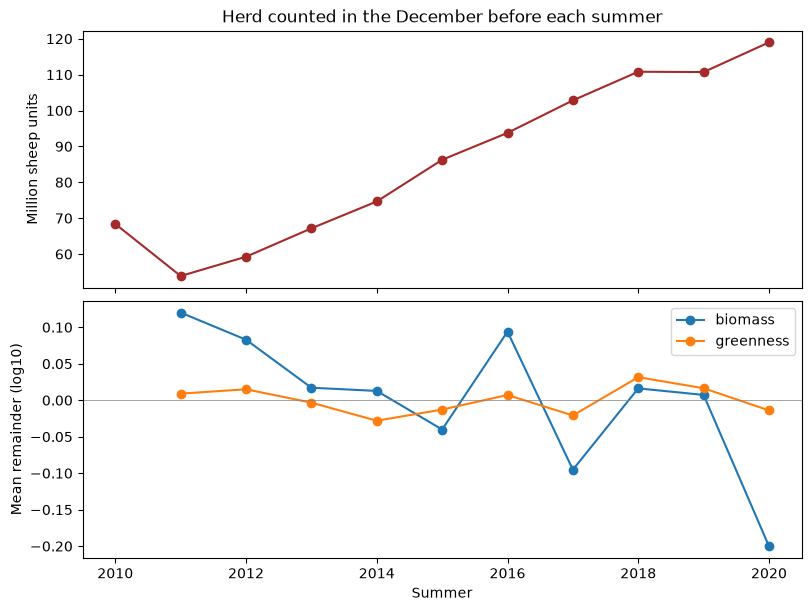

year,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020
million sheep units,68.4,53.9,59.3,67.2,74.7,86.3,93.8,102.8,110.8,110.7,119.0


In [13]:
herd = data.read_herd_before_summer()
herd_national = herd.loc[:, 2010:2020].sum().astype(float)

fig, (top, bottom) = plt.subplots(2, 1, figsize=(8, 6), sharex=True, layout="constrained")
top.plot(herd_national.index, herd_national.values, marker="o", color="brown")
top.set_ylabel("Million sheep units")
top.set_title("Herd counted in the December before each summer")
bottom.plot(yearly.index, yearly["biomass"], marker="o", label="biomass")
bottom.plot(yearly.index, yearly["greenness"], marker="o", label="greenness")
bottom.axhline(0, color="grey", linewidth=0.5)
bottom.set_ylabel("Mean remainder (log10)")
bottom.set_xlabel("Summer")
bottom.legend()
plt.show()
herd_national.round(1).to_frame("million sheep units").T

The dzud cut the herd by a fifth, from 68.4 to 53.9 million sheep units, and it then more than doubled to 119.0 million before summer 2020. Biomass is highest right after the dzud and lowest at the peak. But any two series that trend over the same ten years line up, so the tests compare soums with each other.

In [14]:
soum_zone = weather.groupby("asid")["zone"].first()
green_2019 = weather_remainders(greenness[greenness["year"].between(MAIN_YEARS[0], 2019)], "ndvi")
soum_tables = {"2011-2020": grazing.soum_table(bio_rem, green_main, herd, soum_zone, 2020),
               "2011-2019": grazing.soum_table(bio_2019, green_2019, herd, soum_zone, 2019)}
soums = soum_tables["2011-2020"]

print("Soums:", len(soums), "| without a herd measure:", soums["herd_growth"].isna().sum())
print("Correlation of dzud loss and herd growth:", round(soums["dzud_loss"].corr(soums["herd_growth"]), 2))
print("Herd growth, median soum:", round(10 ** soums["herd_growth"].astype(float).median(), 1), "fold;",
      "middle half:", (10 ** soums["herd_growth"].astype(float).quantile([0.25, 0.75])).round(1).tolist(), "fold")
soums.groupby("zone", observed=True)[["dzud_loss", "herd_growth", "bio_trend", "bio_bump"]].median().reindex(ZONES).round(3)

Soums: 329 | without a herd measure: 7
Correlation of dzud loss and herd growth: 0.67
Herd growth, median soum: 2.2 fold; middle half: [1.8, 2.7] fold


,dzud_loss,herd_growth,bio_trend,bio_bump
zone,,,,
Desert zone,0.184,0.427,-0.446,0.249
Semi desert steppe zone,0.145,0.395,-0.398,0.259
Steppe zone,0.076,0.352,-0.189,0.082
Forest steppe zone,0.084,0.278,0.017,-0.083
Mountain taiga belt,0.023,0.200,0.017,-0.028


The dry zones lost the most animals in the dzud, grew the most after it, and lost the most biomass. If soums were compared across zones, "dry zone" would pass for "herd growth", so the tests compare soums within the same zone. Soums that lost more animals rebuilt more (correlation 0.67), so the two tests are not independent.

In [15]:
tests = [("bio_trend", "herd_growth"), ("bio_bump", "dzud_loss"),
         ("green_trend", "herd_growth"), ("green_bump", "dzud_loss")]
herd_tests = []
for period, table in soum_tables.items():
    for response, driver in tests:
        result = grazing.clustered_test(table, f"{response} ~ {driver} + C(zone)", driver)
        herd_tests.append({"period": period, "response": response, "driver": driver,
                           "soums": result["n"], "aimags": result["clusters"],
                           "slope": round(result["estimate"], 3),
                           "95% range": f"{result['low']:+.3f} to {result['high']:+.3f}",
                           "p": round(result["p"], 3)})
herd_tests = pd.DataFrame(herd_tests)
herd_tests

,period,response,driver,soums,aimags,slope,95% range,p
0,2011-2020,bio_trend,herd_growth,317,21,-0.654,-1.048 to -0.260,0.001
1,2011-2020,bio_bump,dzud_loss,317,21,0.251,-0.162 to +0.664,0.233
2,2011-2020,green_trend,herd_growth,322,21,-0.003,-0.082 to +0.076,0.943
3,2011-2020,green_bump,dzud_loss,322,21,-0.017,-0.074 to +0.040,0.561
4,2011-2019,bio_trend,herd_growth,317,21,-0.372,-0.720 to -0.025,0.036
5,2011-2019,bio_bump,dzud_loss,317,21,0.132,-0.276 to +0.540,0.527
6,2011-2019,green_trend,herd_growth,322,21,0.038,-0.034 to +0.111,0.296
7,2011-2019,green_bump,dzud_loss,322,21,-0.026,-0.083 to +0.030,0.363


In [16]:
# Two extra checks with ordinary errors: the dzud test, and both herd measures in one model
main_table = soum_tables["2011-2020"]
ordinary = smf.ols("bio_bump ~ dzud_loss + C(zone)", data=main_table).fit()
print("Dzud test with ordinary errors: p =", round(ordinary.pvalues["dzud_loss"], 3))
both = smf.ols("bio_trend ~ herd_growth + dzud_loss + C(zone)", data=main_table).fit()
print("Biomass trend on both herd measures:", both.params[["herd_growth", "dzud_loss"]].round(3).to_dict())

Dzud test with ordinary errors: p = 0.024
Biomass trend on both herd measures: {'herd_growth': -0.651, 'dzud_loss': -0.005}


- **Where herds grew more, biomass fell more, within zones.** Compare a soum at the lower quartile of herd growth (1.8-fold) with one at the upper quartile (2.7-fold). Their biomass trends differ by about 0.115 log10 per decade, or 23%. Without 2020 the slope is a little over half as large, and its range still excludes zero.
- **The dzud test finds nothing clear.** Soums that lost more animals had a larger bump in 2011–2013, but the range includes zero. With ordinary instead of clustered errors it would show p = 0.024, which is why the clustering matters.
- **Herd growth carries the link.** With both herd measures in one model, the biomass trend follows herd growth (−0.651) and not dzud loss (−0.005).
- **Greenness follows neither.**

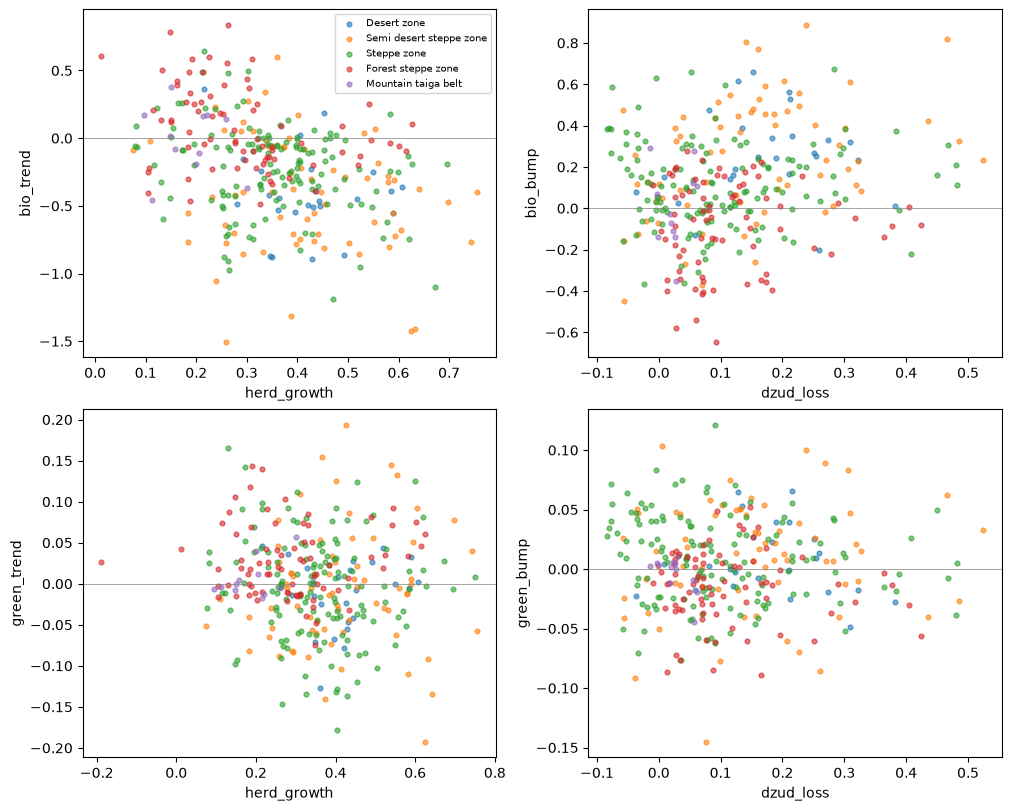

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8), layout="constrained")
for ax, (response, driver) in zip(axes.flat, tests):
    for zone in ZONES:
        zone_soums = soums[soums["zone"] == zone]
        ax.scatter(zone_soums[driver], zone_soums[response], s=12, alpha=0.6, label=zone)
    ax.axhline(0, color="grey", linewidth=0.5)
    ax.set_xlabel(driver)
    ax.set_ylabel(response)
axes[0, 0].legend(fontsize=7)
plt.show()

### When do the fast-growing soums fall behind?

The soums are split into thirds by herd growth, and each soum-year is compared with its zone's mean that year, which takes out weather shared by the whole zone.

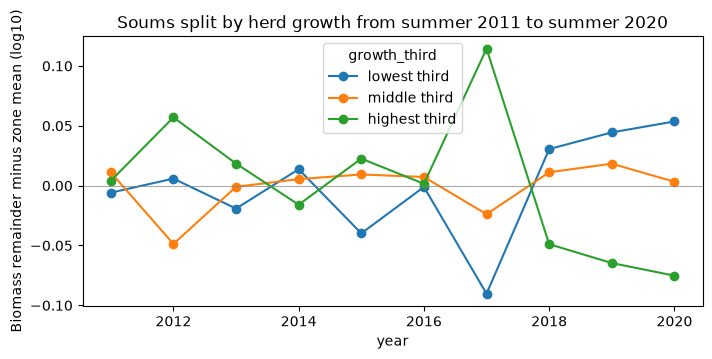

year,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020
growth_third,,,,,,,,,,
lowest third,-0.006,0.006,-0.019,0.014,-0.040,-0.001,-0.090,0.031,0.044,0.054
middle third,0.011,-0.049,-0.001,0.005,0.009,0.007,-0.024,0.011,0.018,0.003
highest third,0.004,0.057,0.018,-0.016,0.023,0.002,0.114,-0.049,-0.065,-0.075


In [18]:
soum_vs_zone = bio_rem.groupby(["asid", "year"])["remainder"].mean().rename("remainder").reset_index()
soum_vs_zone["zone"] = soum_vs_zone["asid"].map(soum_zone)
soum_vs_zone["vs_zone"] = (soum_vs_zone["remainder"]
                           - soum_vs_zone.groupby(["zone", "year"], observed=True)["remainder"].transform("mean"))
growth_third = pd.qcut(soums["herd_growth"].dropna(), 3, labels=["lowest third", "middle third", "highest third"])
soum_vs_zone["growth_third"] = soum_vs_zone["asid"].map(growth_third)
by_third = soum_vs_zone.pivot_table(index="year", columns="growth_third", values="vs_zone", aggfunc="mean", observed=True)

ax = by_third.plot(marker="o", figsize=(8, 3.5))
ax.axhline(0, color="grey", linewidth=0.5)
ax.set_ylabel("Biomass remainder minus zone mean (log10)")
ax.set_title("Soums split by herd growth from summer 2011 to summer 2020")
plt.show()
by_third.round(3).T

The fastest-growing third keeps pace with the others until 2016 and is well above them in the 2017 drought, which a simple grazing story does not explain. It falls below them in 2018, 2019 and 2020, the three summers with the largest herds. The link with herd growth comes from the end of the decade, not from a steady drift.

**In short.** Within zones, soums where herds grew more lost more biomass, also without 2020. That fits grazing, but it is a correlation across soums. Herds may grow faster where early pasture was good, and early highs pull a soum's trend down. The fastest-growing soums lie mostly in the dry zones, where the 2020 drought hit. Herds are counted where they are registered, and they cross soum borders.

## Seasonal pastures

Notebook 1 placed each site on the land agency's seasonal pasture map. Summer-fall ranges are grazed through the summer before the August clipping, and herders leave winter-spring ranges by June. Two tests, set before running them, on site trends with zone baselines and errors clustered by aimag:

- **Trend by pasture type.** Within zones, do sites on summer-fall ranges decline more than sites on winter-spring ranges?
- **Herd link by pasture type.** Is the link between herd growth and biomass decline, found above, stronger on summer-fall ranges?

If animals eating more before the clipping drive the decline, both answers should be yes. A change in the clipping method would show on both pasture types alike.

In [19]:
pasture_of = site_info.set_index("gid")["pasture"]

def pasture_trend_table(remainders, min_years, period):
    """Site trends (log10 per decade) with each site's pasture type, zone, aimag and herd growth."""
    table = trends.site_trends(remainders, min_years=min_years).set_index("gid")
    table["pasture"] = pasture_of
    table["zone"] = remainders.groupby("gid")["zone"].first()
    table["asid"] = remainders.groupby("gid")["asid"].first()
    table["aimag"] = table["asid"] // 100
    table["herd_growth"] = table["asid"].map(soum_tables[period]["herd_growth"])
    return table

pasture_trends = pasture_trend_table(bio_rem, 8, "2011-2020")
print(pasture_trends["pasture"].value_counts().to_dict())
pasture_trends.pivot_table(index="zone", columns="pasture", values="decade", aggfunc="mean").reindex(ZONES).round(3)

{'winter-spring': 640, 'summer-fall': 427, 'outside map': 183}


pasture,outside map,summer-fall,winter-spring
zone,,,
Desert zone,-0.309,-0.608,-0.441
Semi desert steppe zone,-0.314,-0.602,-0.458
Steppe zone,-0.132,-0.309,-0.203
Forest steppe zone,0.062,-0.006,0.010
Mountain taiga belt,-0.061,-0.116,0.052


In [20]:
pasture_tests = []
for period, remainders, min_years in [("2011-2020", bio_rem, 8), ("2011-2019", bio_2019, 7)]:
    on_map = pasture_trend_table(remainders, min_years, period)
    on_map = on_map[on_map["pasture"] != "outside map"].copy()
    on_map["summer"] = (on_map["pasture"] == "summer-fall").astype(int)
    for label, formula, term in [
        ("summer minus winter", "decade ~ summer + C(zone)", "summer"),
        ("herd link on winter-spring", "decade ~ herd_growth * summer + C(zone)", "herd_growth"),
        ("herd link, summer minus winter", "decade ~ herd_growth * summer + C(zone)", "herd_growth:summer"),
    ]:
        result = grazing.clustered_test(on_map, formula, term)
        pasture_tests.append({"period": period, "test": label, "sites": result["n"],
                              "estimate": round(result["estimate"], 3),
                              "95% range": f"{result['low']:+.3f} to {result['high']:+.3f}",
                              "p": round(result["p"], 3)})
pasture_tests = pd.DataFrame(pasture_tests)
pasture_tests

,period,test,sites,estimate,95% range,p
0,2011-2020,summer minus winter,1067,-0.097,-0.198 to +0.004,0.059
1,2011-2020,herd link on winter-spring,1065,-0.770,-1.182 to -0.358,0.000
2,2011-2020,"herd link, summer minus winter",1065,0.263,-0.299 to +0.826,0.359
3,2011-2019,summer minus winter,1067,-0.088,-0.207 to +0.030,0.145
4,2011-2019,herd link on winter-spring,1065,-0.471,-0.849 to -0.092,0.015
5,2011-2019,"herd link, summer minus winter",1065,0.376,-0.141 to +0.893,0.154


In [21]:
# Exploratory, not set in advance: sites outside the map against winter-spring sites
all_sites = pasture_trend_table(bio_rem, 8, "2011-2020")
all_sites["outside"] = (all_sites["pasture"] == "outside map").astype(int)
all_sites["summer"] = (all_sites["pasture"] == "summer-fall").astype(int)
result = grazing.clustered_test(all_sites, "decade ~ outside + summer + C(zone)", "outside")
print(f"Outside the map minus winter-spring: {result['estimate']:+.3f} log10 per decade, "
      f"95% range {result['low']:+.3f} to {result['high']:+.3f}, p = {result['p']:.3f}, sites {result['n']}")

Outside the map minus winter-spring: +0.073 log10 per decade, 95% range -0.010 to +0.156, p = 0.086, sites 1250


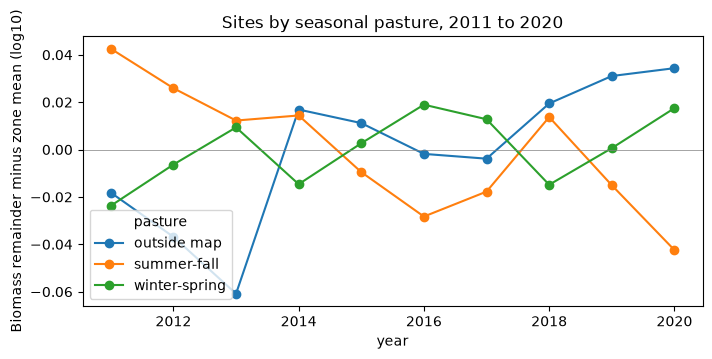

year,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020
pasture,,,,,,,,,,
outside map,-0.018,-0.037,-0.061,0.017,0.011,-0.002,-0.004,0.019,0.031,0.034
summer-fall,0.043,0.026,0.012,0.014,-0.010,-0.028,-0.018,0.014,-0.015,-0.042
winter-spring,-0.024,-0.006,0.009,-0.015,0.003,0.019,0.013,-0.015,0.001,0.017


In [22]:
pasture_years = bio_rem[["gid", "year", "zone", "remainder"]].copy()
pasture_years["vs_zone"] = (pasture_years["remainder"]
                            - pasture_years.groupby(["zone", "year"], observed=True)["remainder"].transform("mean"))
pasture_years["pasture"] = pasture_years["gid"].map(pasture_of)
by_pasture = pasture_years.pivot_table(index="year", columns="pasture", values="vs_zone", aggfunc="mean")

ax = by_pasture.plot(marker="o", figsize=(8, 3.5))
ax.axhline(0, color="grey", linewidth=0.5)
ax.set_ylabel("Biomass remainder minus zone mean (log10)")
ax.set_title("Sites by seasonal pasture, 2011 to 2020")
plt.show()
by_pasture.round(3).T

- **Summer-fall sites declined most.** In every zone they declined more than winter-spring sites, by 0.097 log10 per decade on average, about 20%, and they drift steadily from above their zone to below it. That is the direction grazing before the clipping predicts, but the range includes zero (p = 0.06, and 0.15 without 2020).
- **Winter-spring sites declined too,** by two-thirds to three-quarters as much in the dry zones.
- **The herd link is not stronger on summer-fall sites.** It is clear on winter-spring sites, and summer-fall sites differ by +0.263, which if anything weakens it there.
- **Sites outside the map declined least** in the dry zones, by 0.073 log10 per decade less than winter-spring sites (p = 0.09). That comparison was not set in advance, so it is only a lead.

**In short.** The decline is not confined to land grazed in the summer before the clipping, and the herd link is strongest on winter-spring ranges. Those ranges are not a clean control, though. They are grazed until the end of May, after growth has begun, and herders do not always keep to the map. Records of each site's seasonal use would settle which ranges the plots are on in practice.

## Summary

- **Where and when.** The decline in clipped biomass relative to weather over 2011–2020 lies in the three dry zones. With temperature in the model, about half of it rests on the 2020 drought.
- **Not seen by satellite.** Greenness around the plots shows neither the decline nor its link with herds.
- **Linked to herds.** Within zones, soums where herds grew more lost more biomass, also without 2020, and the link is strongest on winter-spring ranges.
- **Grazing is the leading suspect, but the mechanism is open.** The evidence does not single out animals eating the grass before the August clipping. Longer-lasting effects of more animals fit as well, such as a shift towards unpalatable plants, and so do grazing outside the mapped seasons or factors that go with herd growth. A change in the clipping method is not ruled out.
- **What can decide.** NAMEM's plant groups, seasonal use and records after 2020 can tell these apart.

## Save

In [23]:
outputs = {"soums.csv": soums.reset_index(), "herd_tests.csv": herd_tests, "pasture_tests.csv": pasture_tests}
for name, table in outputs.items():
    table.to_csv(paths.PROCESSED_DIR / name, index=False)
    print(f"Saved {len(table)} rows to data/processed/{name}")

Saved 329 rows to data/processed/soums.csv
Saved 8 rows to data/processed/herd_tests.csv
Saved 6 rows to data/processed/pasture_tests.csv
